## Simulating observational effects for synthetic imaging data cube
To bridge the gap between theoretical models and observational data, it is essential to add observational effects to synthetic data. The ``GalSynMockObservation_imaging`` class in the ``observe`` module transforms idealized synthetic images into realistic mock observations. The process include spatial resapling (to a user-defined pixel scale, matching to the instrument characterictics), PSF convolution, noise simulation and injection. Please refer Abdurro'uf et al. (2026) for detailed descriptions about the method. 

Below, we demonstrate the process of adding observational effects into synthetic images. We will emulate the observational characteristics of the JADES deep imaging observations, specifically the [jw011800-deep subregion](https://slate.ucsc.edu/~brant/jades-dr5/GOODS-S/hlsp/images/submosaics/), as also demonstrated in Abdurro'uf et al. (2026). Please refer to the paper (and reference therein) for more information about the assummed observational characterictics (exposure time, limiting magnitudes, etc.) and how they are obtained. We will use those parameters in the demo below. For the PSFs, we will use empirical PSFs taken from JADES [website](https://slate.ucsc.edu/~brant/jades-dr5/GOODS-N/hlsp/images/submosaics/).  

In [ ]:
import numpy as np
from astropy.io import fits
from galsyn import GalSynMockObservation_imaging
from galsyn.utils import make_filter_transmission_text_pixedfit

# select a set of filters to be processed
filters = ['jwst_nircam_f090w', 'jwst_nircam_f115w', 'jwst_nircam_f150w', 
            'jwst_nircam_f200w', 'jwst_nircam_f277w', 'jwst_nircam_f335m',
            'jwst_nircam_f356w', 'jwst_nircam_f410m', 'jwst_nircam_f444w']

filter_transmission_path1 = make_filter_transmission_text_pixedfit(filters, output_dir="filters")

# Paths to empirical PSF files
psf_paths = {'jwst_nircam_f090w': 'hlsp_jades_jwst_nircam_jw011800-deep_f090w_v5.0_mpsf.fits',
                'jwst_nircam_f115w': 'hlsp_jades_jwst_nircam_jw011800-deep_f115w_v5.0_mpsf.fits',
                'jwst_nircam_f150w': 'hlsp_jades_jwst_nircam_jw011800-deep_f150w_v5.0_mpsf.fits',
                'jwst_nircam_f200w': 'hlsp_jades_jwst_nircam_jw011800-deep_f200w_v5.0_mpsf.fits',
                'jwst_nircam_f277w': 'hlsp_jades_jwst_nircam_jw011800-deep_f277wa_v5.0_mpsf.fits',
                'jwst_nircam_f335m': 'hlsp_jades_jwst_nircam_jw011800-deep_f335ma_v5.0_mpsf.fits',
                'jwst_nircam_f356w': 'hlsp_jades_jwst_nircam_jw011800-deep_f356wa_v5.0_mpsf.fits',
                'jwst_nircam_f410m': 'hlsp_jades_jwst_nircam_jw011800-deep_f410ma_v5.0_mpsf.fits',
                'jwst_nircam_f444w': 'hlsp_jades_jwst_nircam_jw011800-deep_f444wa_v5.0_mpsf.fits'}

# pixel sizes of the PSF images and exposure times
psf_pixel_scales = {}
exposure_time = {}
for ff in filters:
    psf_pixel_scales[ff] = np.sqrt(fits.open(psf_paths[ff])[0].header['PIXAR_A2'])
    exposure_time[ff] = 87.0 * 60.0 * 60.0        # in seconds

# Below, we define the target depth
# Desired limiting magnitudes to be achieved
# For more information about how these quantities are derived, please see Appendix B in Abdurro'uf et al. (2026)
limiting_magnitude = {'jwst_nircam_f090w': 29.875080925253144,
                        'jwst_nircam_f115w': 30.202076521196858,
                        'jwst_nircam_f150w': 30.120139433909824,
                        'jwst_nircam_f200w': 30.146999402885495,
                        'jwst_nircam_f277w': 31.40929981867027,
                        'jwst_nircam_f335m': 30.822006574170356,
                        'jwst_nircam_f356w': 31.261898835117005,
                        'jwst_nircam_f410m': 30.81580759250037,
                        'jwst_nircam_f444w': 30.997602289188894}
# S/N at the limiting magnitude
snr_limit = {ff: 5.0 for ff in filters}
# aperture radius used in measuring the magnitude limits
aperture_radius_arcsec = {ff: 0.15 for ff in filters}

# desired pixel scale
desired_pixel_scales = {ff: 0.03 for ff in filters}

# Magnitude zero-point, derived from ZPAB = –6.10 – 2.5 log10(PIXAR_SR[sr/pix]) 
# with PIXAR_SR is pixel area in steradian
mag_zp = {ff: 28.086519392283982 for ff in filters}

# Input idealized data cube
fits_file_path = 'galsyn_39_107965_photo.fits'

# Initialize the mock observation object
simg = GalSynMockObservation_imaging(fits_file_path, filters, psf_paths, psf_pixel_scales, mag_zp,
                                    limiting_magnitude, snr_limit, aperture_radius_arcsec,
                                    exposure_time, filter_transmission_path1, desired_pixel_scales)

# Start the pipeline: Resampling -> PSF Convolution -> Noise Injection
simg.process_images(apply_noise_to_image=True, dust_attenuation=True)

# Save the resulting science and RMS extensions to a new FITS file
output_fits_path = 'obsimg_galsyn_39_107965_photo_30mas.fits'
simg.save_results_to_fits(output_fits_path=output_fits_path)

Directory 'filters' already exists.

Starting full image processing pipeline...
Processing Filter: jwst_nircam_f090w
Processing Filter: jwst_nircam_f115w
Processing Filter: jwst_nircam_f150w
Processing Filter: jwst_nircam_f200w
Processing Filter: jwst_nircam_f277w
Processing Filter: jwst_nircam_f335m
Processing Filter: jwst_nircam_f356w
Processing Filter: jwst_nircam_f410m
Processing Filter: jwst_nircam_f444w
Results saved to obsimg_galsyn_39_107965_photo_30mas.fits


### Check resulting data cube


In [2]:
from astropy.io import fits 

cube = fits.open('obsimg_galsyn_39_107965_photo_30mas.fits')
cube.info()

Filename: obsimg_galsyn_39_107965_photo_30mas.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       5   ()      
  1  SCI_DUST_JWST_NIRCAM_F090W    1 ImageHDU         9   (345, 345)   float64   
  2  SCI_DUST_JWST_NIRCAM_F115W    1 ImageHDU         9   (345, 345)   float64   
  3  SCI_DUST_JWST_NIRCAM_F150W    1 ImageHDU         9   (345, 345)   float64   
  4  SCI_DUST_JWST_NIRCAM_F200W    1 ImageHDU         9   (345, 345)   float64   
  5  SCI_DUST_JWST_NIRCAM_F277W    1 ImageHDU         9   (345, 345)   float64   
  6  SCI_DUST_JWST_NIRCAM_F335M    1 ImageHDU         9   (345, 345)   float64   
  7  SCI_DUST_JWST_NIRCAM_F356W    1 ImageHDU         9   (345, 345)   float64   
  8  SCI_DUST_JWST_NIRCAM_F410M    1 ImageHDU         9   (345, 345)   float64   
  9  SCI_DUST_JWST_NIRCAM_F444W    1 ImageHDU         9   (345, 345)   float64   
 10  RMS_DUST_JWST_NIRCAM_F090W    1 ImageHDU         9   (345, 345)   float64   
 11  RMS_DUST_JW

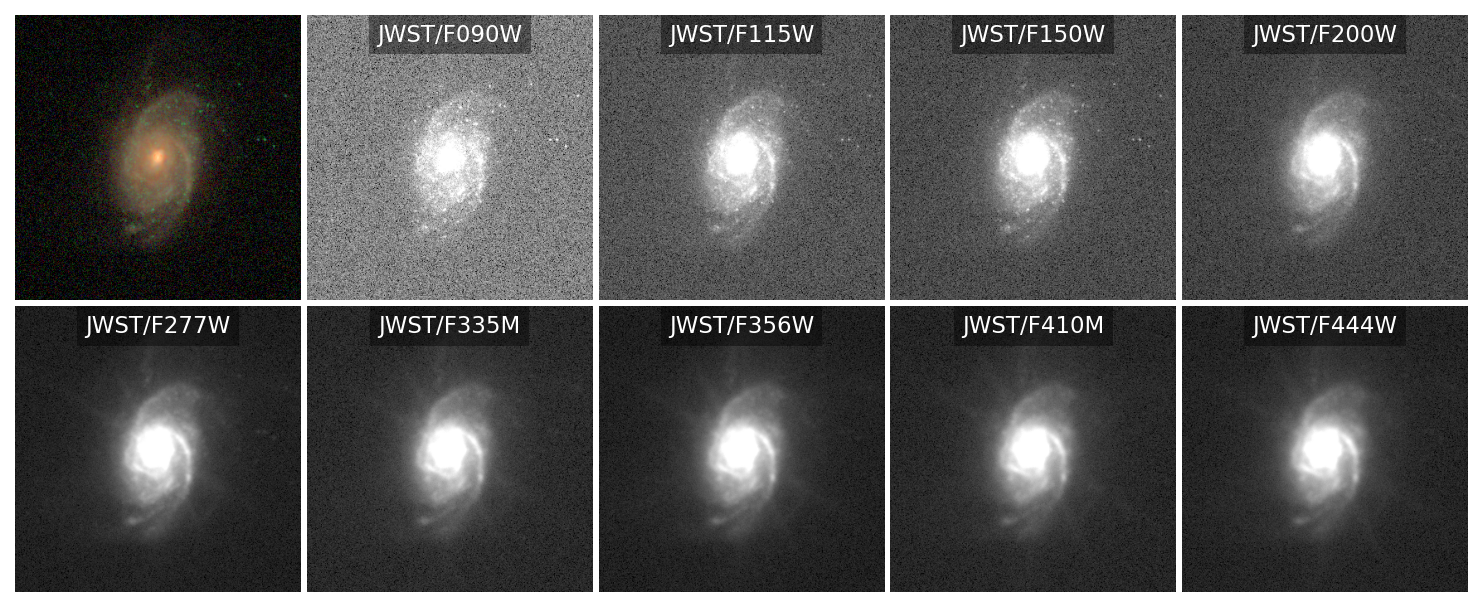

In [3]:
%matplotlib inline

import matplotlib.pyplot as plt
from astropy.visualization import simple_norm, make_lupton_rgb

# Filter configuration
fils = ['jwst_nircam_f090w', 'jwst_nircam_f115w', 'jwst_nircam_f150w', 
            'jwst_nircam_f200w', 'jwst_nircam_f277w', 'jwst_nircam_f335m',
            'jwst_nircam_f356w', 'jwst_nircam_f410m', 'jwst_nircam_f444w']
filnames = ['JWST/F090W', 'JWST/F115W', 'JWST/F150W', 
            'JWST/F200W', 'JWST/F277W', 'JWST/F335M',
            'JWST/F356W', 'JWST/F410M', 'JWST/F444W']
nbands = len(fils)

# RGB components (using JWST NIRCam filters)
rgb_fils = ['jwst_nircam_f115w', 'jwst_nircam_f150w', 'jwst_nircam_f200w']

nrows, ncols = 2, 5
fig = plt.figure(figsize=(ncols*2.5, nrows*2.5), dpi=150)

# RGB Composite
ax_rgb = fig.add_subplot(nrows, ncols, 1)
factor = 2e+3

# Access data using the standard 'DUST[FILTER]' extension name 
r = cube[f'SCI_DUST_{rgb_fils[2]}'].data * factor
g = cube[f'SCI_DUST_{rgb_fils[1]}'].data * factor
b = cube[f'SCI_DUST_{rgb_fils[0]}'].data * factor

rgb = make_lupton_rgb(r, g, b, stretch=50, Q=10)
ax_rgb.imshow(rgb, origin='lower')
ax_rgb.axis('off') # Cleanly removes all ticks and labels

# Individual Grayscale Bands
for ii in range(nbands):
    ax = fig.add_subplot(nrows, ncols, ii+2)
    
    # Access dust-attenuated imaging data 
    data = cube[f'SCI_DUST_{fils[ii]}'].data
    
    # Apply square-root normalization to improve dynamic range visibility
    norm = simple_norm(data, 'sqrt', percent=97.5)
    ax.imshow(data, norm=norm, origin='lower', cmap='gray')
    ax.axis('off')

    # Add filter labels with a small background box for readability
    ax.text(0.5, 0.93, filnames[ii], color='white', fontsize=11,
            ha='center', va='center', transform=ax.transAxes,
            bbox=dict(facecolor='black', alpha=0.4, lw=0))

plt.subplots_adjust(hspace=0.02, wspace=0.02)
plt.show()